# Baseline: Дерево решений

## Цель и гипотезы

Строю два дерева решений как нижнюю планку для CatBoost.

**Дерево 1 (статичное)** - только 22 статичных признака: час, погода, сезон, рабочий день. \
История не используется. Единственный честный baseline для cold start сценария.

**Дерево 2 (с историей)** - все 34 признака, включая lag/rolling/EWM. \
Показывает вклад temporal признаков в простую модель.

### Гипотезы
Сформирую гипотезы, чтобы понять реальный вклад Feature Engineering

1. Дерево 1 даёт идентичные метрики на test, test\_cold и test\_immediate. \
   Проверка cold start immunity: если дерево не использует temporal, история не имеет значения.

2. Дерево 2 значимо превосходит Дерево 1 на чистом test. \
   Temporal признаки несут сигнал даже для простой модели.

3. Дерево 2 с медианным заполнением NaN деградирует на test\_immediate. \
   Медиана lag_1 (~109 велосипедов/час) неверна для ночных часов (реальный спрос 0-10). \
   Демонстрирует, почему CatBoost использует nan\_mode вместо simple imputation.

4. yr = 0% важности в обоих деревьях. \
   В train все строки yr=0, в val/test yr=1. DT не может обучиться на сплите с пустой веткой.

### Точки отсчёта для CatBoost

- Cold start floor: метрики Дерева 1 на test\_immediate
- Warm floor (простая модель): метрики Дерева 2 на test
- CatBoost с nan\_mode должен превосходить оба показателя на соответствующих сплитах

## Импорты и конфигурация

In [34]:
import json
import os
from datetime import date

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from pathlib import Path

In [35]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

mlflow.set_tracking_uri("http://192.168.1.10:5000")
EXPERIMENT_NAME = f"bikeshare_baseline_{date.today().isoformat()}"
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"Experiment: {EXPERIMENT_NAME}")

Experiment: bikeshare_baseline_2026-05-25


## Загрузка данных

In [36]:
train          = pd.read_csv("datasets/clean/train.csv")
val            = pd.read_csv("datasets/clean/validation.csv")
test           = pd.read_csv("datasets/clean/test.csv")
test_cold      = pd.read_csv("datasets/clean/test_cold.csv")
test_immediate = pd.read_csv("datasets/clean/test_immediate.csv")

TARGET = "cnt"

TEMPORAL_COLS = [
    "cnt_lag_1", "cnt_lag_3", "cnt_lag_6", "cnt_lag_12", "cnt_lag_24",
    "cnt_rolling_mean_3", "cnt_rolling_mean_6", "cnt_rolling_mean_12", "cnt_rolling_mean_24",
    "cnt_rolling_std_6", "cnt_rolling_std_12", "cnt_ewm_6h",
]

feature_cols = [c for c in train.columns if c != TARGET]
STATIC_COLS  = [c for c in feature_cols if c not in TEMPORAL_COLS]

print(f"Признаков всего:  {len(feature_cols)}")
print(f"  Статичных:      {len(STATIC_COLS)}")
print(f"  Temporal:       {len(TEMPORAL_COLS)}")

Признаков всего:  34
  Статичных:      22
  Temporal:       12


In [37]:
pd.DataFrame(
    {
        "строк": [len(train), len(val), len(test), len(test_cold), len(test_immediate)],
        "temporal_nan": [
            df[TEMPORAL_COLS].isna().sum().sum()
            for df in [train, val, test, test_cold, test_immediate]
        ],
    },
    index=["train", "val", "test", "test_cold", "test_immediate"],
)

,строк,temporal_nan
train,8645,15375
val,4358,0
test,4376,0
test_cold,4376,8320
test_immediate,4376,52512


## Функция метрик

Данные хранят cnt в log1p-пространстве (преобразование из notebook 02). \
Все метрики считаются из log-предсказаний через expm1.

- RMSLE: RMSE в log-пространстве, что минимизирует дерево
- RMSE, MAE: в оригинальных велосипедах/час, интерпретируемы операционно
- R2: в log-пространстве

In [38]:
def eval_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_pred = np.clip(y_pred, 0.0, None)
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred)
    return {
        "rmsle": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "rmse":  float(np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))),
        "mae":   float(mean_absolute_error(y_true_orig, y_pred_orig)),
        "r2":    float(r2_score(y_true, y_pred)),
    }

## Дерево 1: статичные признаки

Используются только 22 статичных признака. Temporal колонки исключены полностью.

NaN в статичных признаках отсутствуют (маскирование в notebook 02 затронуло только temporal). \
fillna добавлен для корректности pipeline.

In [39]:
train_median_s = train[STATIC_COLS].median()

X_train_s = train[STATIC_COLS].fillna(train_median_s)
X_val_s   = val[STATIC_COLS].fillna(train_median_s)
X_test_s  = test[STATIC_COLS].fillna(train_median_s)
X_cold_s  = test_cold[STATIC_COLS].fillna(train_median_s)
X_imm_s   = test_immediate[STATIC_COLS].fillna(train_median_s)

y_train = train[TARGET].values
y_val   = val[TARGET].values
y_test  = test[TARGET].values
y_cold  = test_cold[TARGET].values
y_imm   = test_immediate[TARGET].values

In [40]:
dt_static = DecisionTreeRegressor(max_depth=4, random_state=RANDOM_SEED)
dt_static.fit(X_train_s, y_train)

metrics_static = {
    "train":          eval_metrics(y_train, dt_static.predict(X_train_s)),
    "val":            eval_metrics(y_val,   dt_static.predict(X_val_s)),
    "test":           eval_metrics(y_test,  dt_static.predict(X_test_s)),
    "test_cold":      eval_metrics(y_cold,  dt_static.predict(X_cold_s)),
    "test_immediate": eval_metrics(y_imm,   dt_static.predict(X_imm_s)),
}

pd.DataFrame(metrics_static).T.round(4)

,rmsle,rmse,mae,r2
train,0.6237,77.5220,51.6702,0.7934
val,0.7843,155.9156,103.1999,0.7055
test,0.7793,181.6276,124.3029,0.6859
test_cold,0.7793,181.6276,124.3029,0.6859
test_immediate,0.7793,181.6276,124.3029,0.6859


### Проверка гипотезы 1: cold start immunity

Метрики test, test\_cold и test\_immediate должны быть идентичными. \
Дерево использует только статичные признаки - удаление или заполнение temporal не влияет на предсказания.

**Разрывы, которые нужно объяснить:**

- train vs val: обучение и оценка на разных периодах (2011 vs первое полугодие 2012). \
  Умеренный gap показывает нормальное обобщение.

- val vs test: test - июль-декабрь 2012, пик сезона с высоким абсолютным спросом. \
  RMSE на test выше даже при схожем RMSLE: больше high-demand часов = крупнее абсолютные ошибки.

- train R2=0.793 vs val R2=0.706: умеренный разрыв, ожидаемый для depth=4. \
  Дерево недообучено (16 листьев на 22 признаках), но не переобучено.

In [41]:
with mlflow.start_run(run_name="dt_static_depth4"):
    mlflow.log_params({
        "model_type":  "DecisionTreeRegressor",
        "max_depth":   4,
        "random_seed": RANDOM_SEED,
        "feature_set": "static_only",
        "n_features":  len(STATIC_COLS),
        "train_rows":  len(train),
    })
    for split, m in metrics_static.items():
        for k, v in m.items():
            mlflow.log_metric(f"{split}_{k}", v)
    print("Залогировано: dt_static_depth4")

Залогировано: dt_static_depth4
🏃 View run dt_static_depth4 at: http://192.168.1.10:5000/#/experiments/4/runs/0c912b88cfd74227bc29910c9326dbc4
🧪 View experiment at: http://192.168.1.10:5000/#/experiments/4


## Структура Дерева 1

Дерево глубины 4, не более 16 листьев. Значения листьев в log-пространстве.

Перевод ключевых значений через expm1:

| log-значение | вел/час |
|---|---|
| 1.40 | 3.1 |
| 1.56 | 3.8 |
| 2.35 | 9.5 |
| 2.76 | 14.8 |
| 2.86 | 16.4 |
| 3.45 | 30.5 |
| 3.85 | 45.9 |
| 3.97 | 52.9 |
| 4.47 | 86.3 |
| 4.53 | 91.8 |
| 4.99 | 145.8 |
| 5.27 | 193.9 |
| 5.29 | 197.7 |
| 5.60 | 269.1 |
| 5.92 | 371.5 |

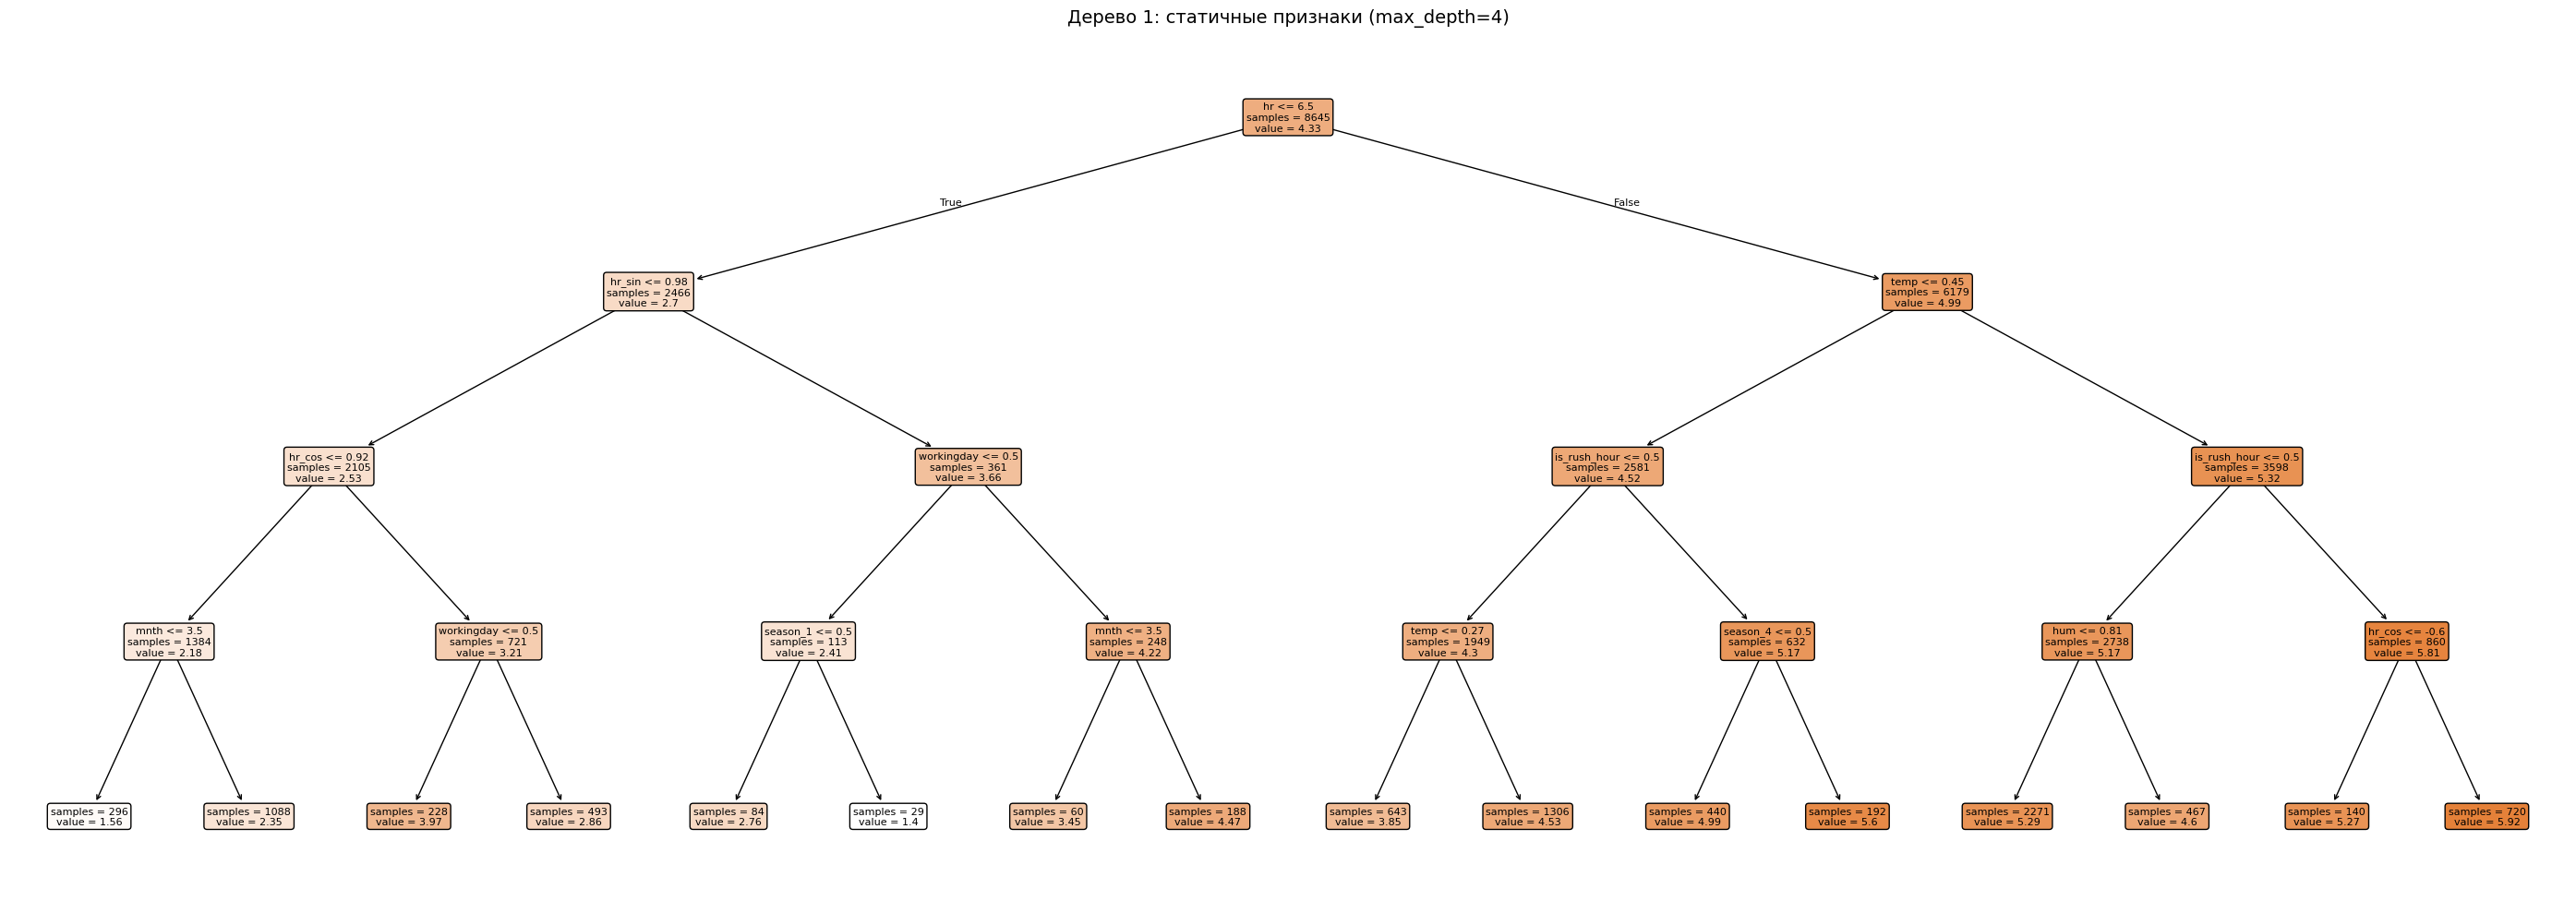

In [42]:
fig, ax = plt.subplots(figsize=(28, 10))
plot_tree(
    dt_static,
    feature_names=STATIC_COLS,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=False,
    precision=2,
)
plt.title("Дерево 1: статичные признаки (max_depth=4)", fontsize=14)
plt.tight_layout()
plt.show()

In [43]:
print(export_text(dt_static, feature_names=STATIC_COLS, max_depth=4))

|--- hr <= 6.50
|   |--- hr_sin <= 0.98
|   |   |--- hr_cos <= 0.92
|   |   |   |--- mnth <= 3.50
|   |   |   |   |--- value: [1.56]
|   |   |   |--- mnth >  3.50
|   |   |   |   |--- value: [2.35]
|   |   |--- hr_cos >  0.92
|   |   |   |--- workingday <= 0.50
|   |   |   |   |--- value: [3.97]
|   |   |   |--- workingday >  0.50
|   |   |   |   |--- value: [2.86]
|   |--- hr_sin >  0.98
|   |   |--- workingday <= 0.50
|   |   |   |--- season_1 <= 0.50
|   |   |   |   |--- value: [2.76]
|   |   |   |--- season_1 >  0.50
|   |   |   |   |--- value: [1.40]
|   |   |--- workingday >  0.50
|   |   |   |--- mnth <= 3.50
|   |   |   |   |--- value: [3.45]
|   |   |   |--- mnth >  3.50
|   |   |   |   |--- value: [4.47]
|--- hr >  6.50
|   |--- temp <= 0.45
|   |   |--- is_rush_hour <= 0.50
|   |   |   |--- temp <= 0.27
|   |   |   |   |--- value: [3.85]
|   |   |   |--- temp >  0.27
|   |   |   |   |--- value: [4.53]
|   |   |--- is_rush_hour >  0.50
|   |   |   |--- season_4 <= 0.50
|   | 

### Интерпретация логики дерева

**Ветка hr <= 6.5 (ночь, 0-6 часов)**

Дерево использует hr_sin и hr_cos внутри ночного блока вместо hr напрямую

Пороги в переводе:
- hr_cos > 0.92 соответствует hr=0 и hr=1 (полночь, час ночи): weekend 52.9, workday 16.4 вел/час
  - Ночная жизнь. В выходные спрос выше в 3 раза
- hr_sin > 0.98 соответствует hr=6 (рассвет): рабочий день апр-дек уже 86.3 вел/час
  - Утренний пик нарастает
- Глубокая ночь hr=2-5: 3.8-9.5 вел/час в зависимости от месяца. Минимальный спрос

**Ветка hr > 6.5 (день, 7-23 часа)**

Первый сплит по temp=0.45, что соответствует примерно 18.5 градусов Цельсия.

Прохладная погода (temp <= 0.45):
- Вне часов пик: 45.9 (холодно, temp <= 0.27) или 91.8 (прохладно) вел/час
- Часы пик: 145.8 (не осень) или 269.1 (осень) вел/час
  - Осенью холоднее, но люди ещё активны - это пик осеннего спроса

Теплая погода (temp > 0.45):
- Вне часов пик: 197.7 при нормальной влажности (hum <= 0.81) или 98.7 при высокой
  - Высокая влажность снижает спрос вдвое - дождь отпугивает
- Часы пик warm + is\_rush\_hour: hr_cos <= -0.60 соответствует hr=9 (хвост утреннего пика) -> 193.9
  - hr_cos > -0.60 соответствует hr=7,8,17,18,19 (ядро утреннего и вечернего пика) -> 371.5
  - Дерево через hr_cos разделяет хвост пика (9 утра, уже спадает) от ядра (7-8 утра, 17-19 вечера)

**Признак yr: 0% важности**

yr не используется в дереве. Причина структурная: в train все строки yr=0, в val/test yr=1. При обучении сплит yr > 0.5 даёт одну ветку со всеми обучающими примерами и одну пустую. Пустая ветка не несёт информации, поэтому дерево никогда не выбирает yr для разбиения. Сезонность и month частично компенсируют отсутствие yr

### Важность признаков и качество предсказаний

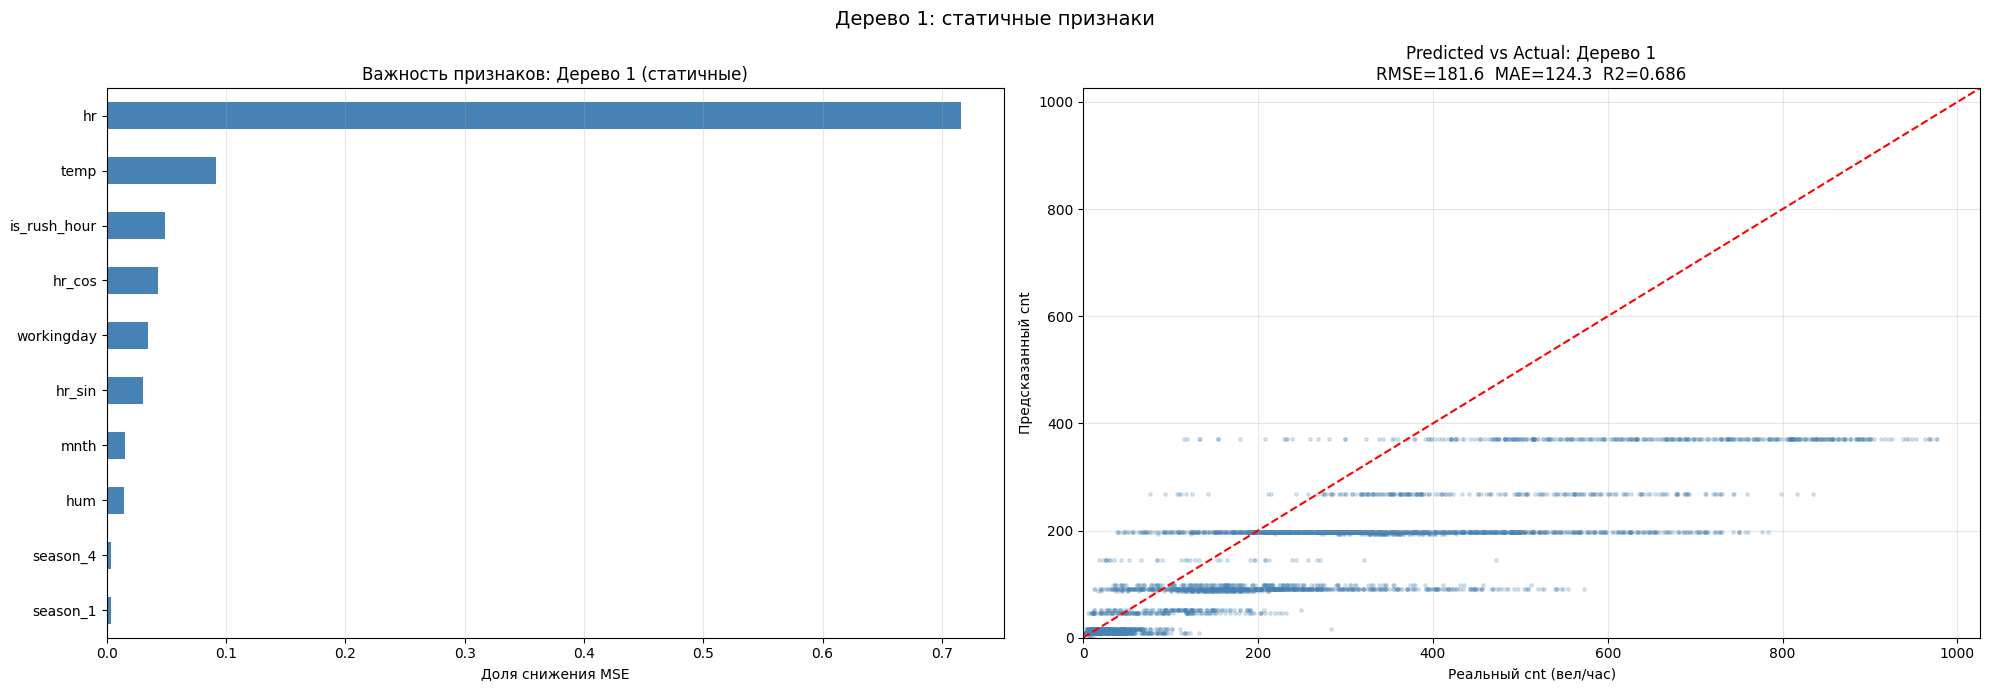


Топ признаков:
hr              0.7161
temp            0.0916
is_rush_hour    0.0488
hr_cos          0.0428
workingday      0.0346
hr_sin          0.0302
mnth            0.0148
hum             0.0143


In [44]:
fi_static = pd.Series(
    dt_static.feature_importances_, index=STATIC_COLS
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

fi_static[fi_static > 0].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Важность признаков: Дерево 1 (статичные)")
axes[0].set_xlabel("Доля снижения MSE")
axes[0].grid(axis="x", alpha=0.3)

y_true_orig = np.expm1(y_test)
y_pred1_orig = np.expm1(dt_static.predict(X_test_s))
m1 = metrics_static["test"]

axes[1].scatter(y_true_orig, y_pred1_orig, alpha=0.2, s=6, color="steelblue")
lim = max(y_true_orig.max(), y_pred1_orig.max()) * 1.05
axes[1].plot([0, lim], [0, lim], "r--", linewidth=1.5)
axes[1].set_xlabel("Реальный cnt (вел/час)")
axes[1].set_ylabel("Предсказанный cnt")
axes[1].set_title(
    f"Predicted vs Actual: Дерево 1\n"
    f"RMSE={m1['rmse']:.1f}  MAE={m1['mae']:.1f}  R2={m1['r2']:.3f}"
)
axes[1].set_xlim(0, lim)
axes[1].set_ylim(0, lim)
axes[1].grid(alpha=0.3)

plt.suptitle("Дерево 1: статичные признаки", fontsize=14)
plt.tight_layout()
plt.show()

print("\nТоп признаков:")
print(fi_static[fi_static > 0.005].sort_values(ascending=False).round(4).to_string())

## Дерево 2: все признаки (с temporal)

Добавляю все 12 temporal признаков: lag\_1/3/6/12/24, rolling\_mean\_3/6/12/24, rolling\_std\_6/12, ewm\_6h

NaN в train (cold start masking из notebook 02) заполняю медианой из train. Для test\_immediate это означает: все temporal заполнены медианой ~109 вел/час. Это грубая аппроксимация - медиана соответствует дневному спросу, не ночному. CatBoost решает эту проблему через nan\_mode='Min' без ручного заполнения

In [45]:
train_median_all = train[feature_cols].median()

X_train_t = train[feature_cols].fillna(train_median_all)
X_val_t   = val[feature_cols].fillna(train_median_all)
X_test_t  = test[feature_cols].fillna(train_median_all)
X_cold_t  = test_cold[feature_cols].fillna(train_median_all)
X_imm_t   = test_immediate[feature_cols].fillna(train_median_all)

In [46]:
dt_temporal = DecisionTreeRegressor(max_depth=4, random_state=RANDOM_SEED)
dt_temporal.fit(X_train_t, y_train)

metrics_temporal = {
    "train":          eval_metrics(y_train, dt_temporal.predict(X_train_t)),
    "val":            eval_metrics(y_val,   dt_temporal.predict(X_val_t)),
    "test":           eval_metrics(y_test,  dt_temporal.predict(X_test_t)),
    "test_cold":      eval_metrics(y_cold,  dt_temporal.predict(X_cold_t)),
    "test_immediate": eval_metrics(y_imm,   dt_temporal.predict(X_imm_t)),
}

pd.DataFrame(metrics_temporal).T.round(4)

,rmsle,rmse,mae,r2
train,0.5083,65.0482,41.9818,0.8628
val,0.4781,107.4589,66.9015,0.8906
test,0.5072,134.9791,83.7863,0.8670
test_cold,0.5623,148.6398,91.7177,0.8365
test_immediate,1.1064,238.5696,169.4393,0.3670


In [47]:
with mlflow.start_run(run_name="dt_temporal_depth4"):
    mlflow.log_params({
        "model_type":   "DecisionTreeRegressor",
        "max_depth":    4,
        "random_seed":  RANDOM_SEED,
        "feature_set":  "all_features",
        "n_features":   len(feature_cols),
        "train_rows":   len(train),
        "nan_strategy": "fillna_median",
    })
    for split, m in metrics_temporal.items():
        for k, v in m.items():
            mlflow.log_metric(f"{split}_{k}", v)
    print("Залогировано: dt_temporal_depth4")

Залогировано: dt_temporal_depth4
🏃 View run dt_temporal_depth4 at: http://192.168.1.10:5000/#/experiments/4/runs/873fe59f362e41569de3cccc41305758
🧪 View experiment at: http://192.168.1.10:5000/#/experiments/4


## Сравнение двух деревьев

Сопоставляю метрики на одинаковых сплитах. \
Знак delta: отрицательный = temporal лучше, положительный = temporal хуже.

In [48]:
from IPython.display import display

rows = []
for split in ["train", "val", "test", "test_cold", "test_immediate"]:
    ms = metrics_static[split]
    mt = metrics_temporal[split]
    rows.append({
        "split":          split,
        "static_rmsle":   round(ms["rmsle"], 4),
        "temporal_rmsle": round(mt["rmsle"], 4),
        "delta_rmsle":    round(mt["rmsle"] - ms["rmsle"], 4),
        "static_r2":      round(ms["r2"], 4),
        "temporal_r2":    round(mt["r2"], 4),
        "static_rmse":    round(ms["rmse"], 1),
        "temporal_rmse":  round(mt["rmse"], 1),
    })

display(pd.DataFrame(rows).set_index("split"))

,static_rmsle,temporal_rmsle,delta_rmsle,static_r2,temporal_r2,static_rmse,temporal_rmse
split,,,,,,,
train,0.6237,0.5083,-0.1154,0.7934,0.8628,77.5,65.0
val,0.7843,0.4781,-0.3062,0.7055,0.8906,155.9,107.5
test,0.7793,0.5072,-0.2721,0.6859,0.8670,181.6,135.0
test_cold,0.7793,0.5623,-0.2170,0.6859,0.8365,181.6,148.6
test_immediate,0.7793,1.1064,0.3271,0.6859,0.3670,181.6,238.6


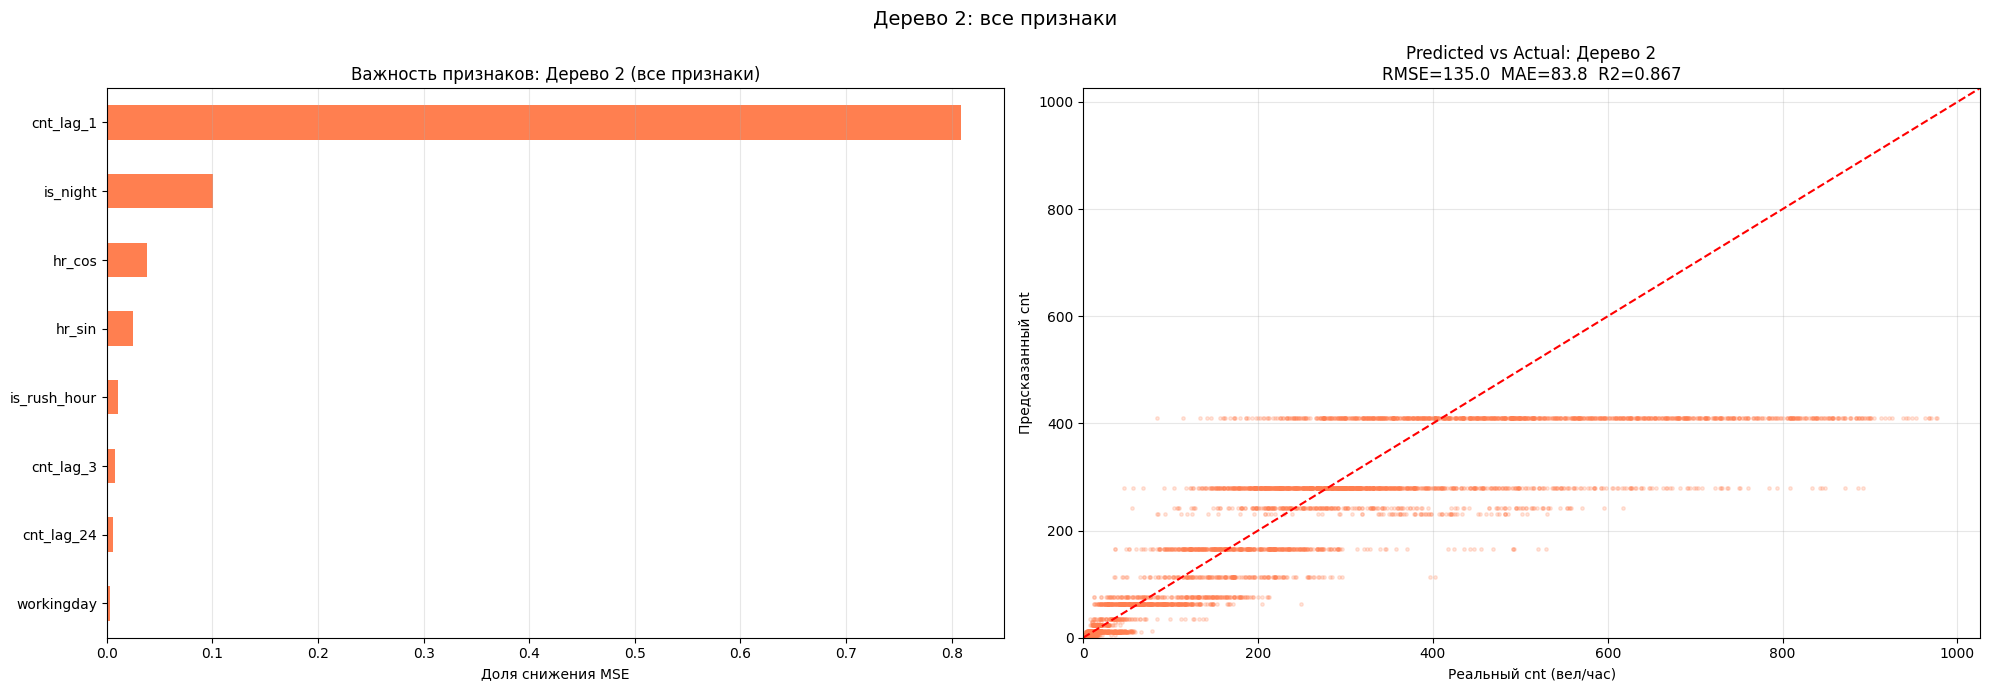


Топ признаков:
cnt_lag_1       0.8088
is_night        0.1008
hr_cos          0.0378
hr_sin          0.0246
is_rush_hour    0.0109
cnt_lag_3       0.0080
cnt_lag_24      0.0057


In [49]:
fi_temporal = pd.Series(
    dt_temporal.feature_importances_, index=feature_cols
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

fi_temporal[fi_temporal > 0].plot(kind="barh", ax=axes[0], color="coral")
axes[0].set_title("Важность признаков: Дерево 2 (все признаки)")
axes[0].set_xlabel("Доля снижения MSE")
axes[0].grid(axis="x", alpha=0.3)

y_pred2_orig = np.expm1(dt_temporal.predict(X_test_t))
m2 = metrics_temporal["test"]

axes[1].scatter(y_true_orig, y_pred2_orig, alpha=0.2, s=6, color="coral")
lim2 = max(y_true_orig.max(), y_pred2_orig.max()) * 1.05
axes[1].plot([0, lim2], [0, lim2], "r--", linewidth=1.5)
axes[1].set_xlabel("Реальный cnt (вел/час)")
axes[1].set_ylabel("Предсказанный cnt")
axes[1].set_title(
    f"Predicted vs Actual: Дерево 2\n"
    f"RMSE={m2['rmse']:.1f}  MAE={m2['mae']:.1f}  R2={m2['r2']:.3f}"
)
axes[1].set_xlim(0, lim2)
axes[1].set_ylim(0, lim2)
axes[1].grid(alpha=0.3)

plt.suptitle("Дерево 2: все признаки", fontsize=14)
plt.tight_layout()
plt.show()

print("\nТоп признаков:")
print(fi_temporal[fi_temporal > 0.005].sort_values(ascending=False).round(4).to_string())

### Интерпретация результатов сравнения

**Гипотеза 2: temporal дают значимый прирост - подтверждена**

На чистом test: RMSLE 0.779 стал 0.507 (улучшение -0.272), RMSE 181.6 стал 134.9 (-46.6 вел/час). Прирост R2 с 0.686 до 0.867 - temporal объясняют дополнительно 18% дисперсии

**Гипотеза 3: деградация на test_immediate - подтверждена**

Дерево 2 на test\_immediate: RMSLE=1.106 vs Дерево 1: RMSLE=0.779. Temporal DT с медианным заполнением ХУЖЕ статичного дерева при полном cold start

Причина: медиана cnt\_lag\_1 = 109 вел/час (типичный дневной спрос). Для ночных часов (реальный спрос 0-10 вел/час) это значение полностью неверно. Дерево обучилось использовать lag\_1 как главный признак (80.8% FI), поэтому плохое заполнение NaN разрушает все предсказания при нулевой истории

is\_night с 10.1% FI - это попытка дерева частично скомпенсировать вред медианного lag

**Гипотеза 4: yr = 0% FI - подтверждена в обоих деревьях**

Структурное ограничение хронологического сплита сохраняется и при добавлении temporal

**FI Дерева 2: cnt\_lag\_1 = 80.8%**

Дерево с глубиной 4 строит почти всю структуру вокруг одного признака - последнего часа. Это отражает высокую автокорреляцию ряда (ACF лаг 1 ~ 0.85, из EDA). При depth=4 остаётся мало листьев для дополнительного контекста через другие признаки

**test\_cold: RMSLE=0.562 vs test: 0.507**

Деградация умеренная: 20% строк в test\_cold имеют частичный или полный cold start. Дерево справляется с mixed cold start лучше, чем с полным (test\_immediate).

## Выводы для CatBoost

### Референсные значения метрик

| Сценарий | Модель | RMSLE | RMSE | R2 |
|---|---|---|---|---|
| test (полная история) | Дерево 1 (static) | 0.779 | 181.6 | 0.686 |
| test (полная история) | Дерево 2 (temporal) | 0.507 | 134.9 | 0.867 |
| test\_immediate (zero history) | Дерево 1 (static) | 0.779 | 181.6 | 0.686 |
| test\_immediate (zero history) | Дерево 2 + median | 1.106 | 238.6 | 0.367 |

### Минимальные требования к CatBoost

1. На test: RMSLE < 0.507 и RMSE < 134.9. Иначе глубокая модель не оправдана.

2. На test\_immediate: RMSLE < 0.779. \
   CatBoost с nan\_mode='Min' должен обрабатывать cold start лучше медианного заполнения.    Если это не так, nan\_mode нужно пересмотреть

3. На test\_cold: RMSLE < 0.562 (ориентир Дерева 2 с mixed NaN).

### Ключевые наблюдения из деревьев

- hr доминирует в статичной модели (71.6% FI). CatBoost будет на него полагаться через более гибкие взаимодействия: hr * workingday, hr * season и т.д.
- cnt\_lag\_1 доминирует в temporal модели (80.8% FI). CatBoost при наличии истории будет сильно опираться на лаги. Это означает, что nan\_mode критичен для cold start
- Влажность hum снижает спрос при hum > 0.81 (в теплую погоду: 197 -> 98 вел/час). CatBoost нужно проверить взаимодействие temp * hum
- is\_rush\_hour с 4.9% FI дерево реально использует как самостоятельный признак. CatBoost должен его подхватить, возможно с более высоким весом через взаимодействия
- yr остался нулевым в обоих деревьях. CatBoost может извлечь из yr информацию через взаимодействие с temporal признаками, которые несут "сейчас" независимо от номера года

## Сохранение модели

In [50]:
Path("models/baseline_decision_tree_regressor").mkdir(exist_ok=True)

joblib.dump(dt_static, "models/baseline_decision_tree_regressor/model.pkl")

metadata = {
    "model":            "DecisionTreeRegressor",
    "variant":          "static_features_only",
    "max_depth":        4,
    "random_seed":      RANDOM_SEED,
    "features":         STATIC_COLS,
    "n_features":       len(STATIC_COLS),
    "target":           TARGET,
    "target_transform": "log1p",
    "metrics": {
        "val":            metrics_static["val"],
        "test":           metrics_static["test"],
        "test_immediate": metrics_static["test_immediate"],
    },
}
with open("models/baseline_decision_tree_regressor/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Сохранено:")
print("  models/baseline_decision_tree_regressor/model.pkl")
print("  models/baseline_decision_tree_regressor/metadata.json")

Сохранено:
  models/baseline_decision_tree_regressor/model.pkl
  models/baseline_decision_tree_regressor/metadata.json
